# Multi-Hyperuniform optimization

***

In `point_distribution_optimization.ipynb`, we looked at how `tostada.Optimization` can be used to tune the coordinates of a point distribution to have a specific reciprocal-space response, that is, to create non-intuitive disordered hyperuniform configurations. The versatility of this module can be further appreciated by classifying different species (with different particle properties) within the point-distribution and optimizing the reciprocal-space response of each species, individually as well collectively as a system, simultaneously. In the context of hyperuniformity, such systems are called _multi-hyperuniform systems_.

In [1]:
import numpy as np
import tostada as tost
#import matplotlib.pyplot as plt
#from tostada.PointDistribution import PointDistribution
#import tostada.Optimization as topt
#from tostada.pointprocess import Pointprocess

First, let us create a point-distribution with a given diameter for each particle. Again, we choose random sequential adsorption process as the initial positions.

In [2]:
process = tost.Pointprocess(BoxSize=10,
                       diameter=0.3,
                       ax = 0.5)
points = process.RandomSequentialAdsorption(sdev_histo=0.07)

Estimated particles to be deposited=400 with mean inter-particle distance=0.5
number of experiments:1577300): |------------------------------| 1.6% Current FF=3.990 of 4.000


To ensure each species and the collective system maintains no overlapping particles, we can use `PointDistribution.overlap()` to track any overlaps throughout the notebook. It quantifies overlapping particles within a given distance _D0_ where _D0_ is the diameter of the particles. **For non-overlapping particles (like RSA type process), this should be zero.**

<Axes: title={'center': 'Point Distribution, mean interparticle distance = 0.5'}, xlabel='X ($\\mu$m)', ylabel='Y ($\\mu$m)'>

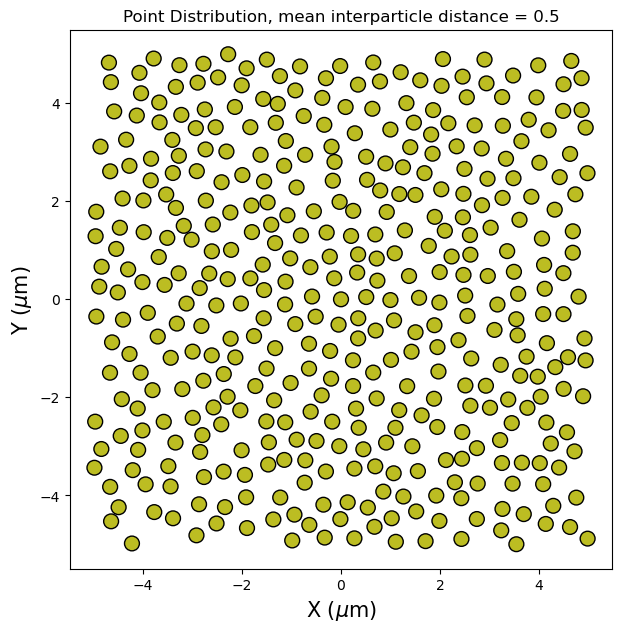

In [3]:
fig = tost.Visualize(points)
fig.plot_distribution()

In [4]:
points.overlap(D0=points.diameter)[0]

0.0

Now, let us imagine this distribution of N particles to be made up of 3 species each with different diameter (but not greater than original distribution). Particles per species is then simply total number of particles in the original distribution / 3

In [5]:
num_species = 3 
particles_per_species = int(points.totalparticles/num_species)

**But the question still remains; how can these 3 species be individually placed inside the system such that each species is disordered hyperuniform while also keeping the entire system to be hyperuniform?**

For this, we shall carry out 3 optimizations instead of 1 (as shown in `points_distribution_optimization.ipynb`) with each optimization only tuning the positions of one species. 

We can track the movement of each particle from `points.positions` by assigning indices to each.

In [6]:
Species = np.zeros([num_species,particles_per_species],dtype=np.int64) # total number of elements => total number of particles
for i in range(num_species):
    j = i*particles_per_species
    Species[i] = np.arange(j,j+particles_per_species)

Since the number of particles in each species is now less but they are contained in the same `PointDistribution.BoxSize`, the mean distance between each would be greater than the system.

In [7]:
Dmean = 1/np.sqrt(particles_per_species/(points.Lx*points.Ly)) # interparticle distance of each species
print (Dmean, points.dmean)

0.8648088226536912 0.5


Now, lets call the optimizer...

In [9]:
opt = tost.Optimization(points)

##### We aim to create stealthy disordered hyperuniform state with stealth parameter $\chi=0.4$. For the given interparticle distance (per species), this sets the upper-bound $q_f$ such that $S(0 < q < q_f) = 0$

In [10]:
q_f = points.Q_from_chi(0.4,dmean=Dmean)
print (q_f)

5.184952853925656


The optimizer can now optimize the particle positions to create the above structure factor. But unlike the previous case from `points_distribution_optimization.ipynb`, here we wish to separate the particles that have to be moved versus ones that are fixed. This can be specified by `positions` and `masked_pos` options, respectively.

#### <span style="color:red">Note : These options were unused in the previous notebook since not specifying them simply takes all the positions are variables and assumes zero masking.</span>


In [11]:
input = points.positions[Species[0]][:,:-1]
masked_pos = None

opt_r = opt.optimize(q_f = q_f,
                     D0=0.3,
                     positions=input,
                     masked_pos=masked_pos)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/home/pdhawan/miniconda3/envs/tost/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/pdhawan/miniconda3/envs/tost/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          266     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  5.25288D-01    |proj g|=  1.50734D-01

At iterate    1    f=  2.10728D-01    |proj g|=  5.80355D-02

At iterate    2    f=  1.27599D-01    |proj g|=  3.18266D-02

At iterate    3    f=  6.69561D-02    |proj g|=  1.60287D-02

At iterate    4    f=  3.52401D-02    |proj g|=  7.69134D-03

At iterate    5    f=  1.67782D-02    |proj g|=  7.31777D-03

At iterate    6    f=  1.11809D-02    |proj g|=  6.75685D-03

At iterate    7    f=  7.09195D-03    |proj g|=  3.28488D-03

At iterate    8    f=  5.57954D-03    |proj g|=  2.38805D-03

At iterate    9    f=  3.59239D-03    |proj g|=  1.87172D-03

At iterate   10    f=  2.33383D-03    |proj g|=  1.28750D-03

At iterate   11    f=  1.58027D-03    |proj g|=  9.46038D-04

At iterate   12    f=  9.32972D-04    |proj g|=  7.26460D-04

At iterate   13    f=  5.9

We can declare this species as a separate `PointDistribution` to separate its individual properties from the overall system.

In [12]:
opt_state1 = tost.PointDistribution(opt.opt_positions,diameter=points.diameter,BoxSize=points.BoxSize)

#### Sanity check for ensuring no overlapping particles...

In [13]:
opt_state1.overlap(D0=points.diameter)[0]

0.0

[<Axes: title={'center': 'Reciprocal Space, Structure Factor $S(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{S}(|\\mathbf{q}|)$'>]

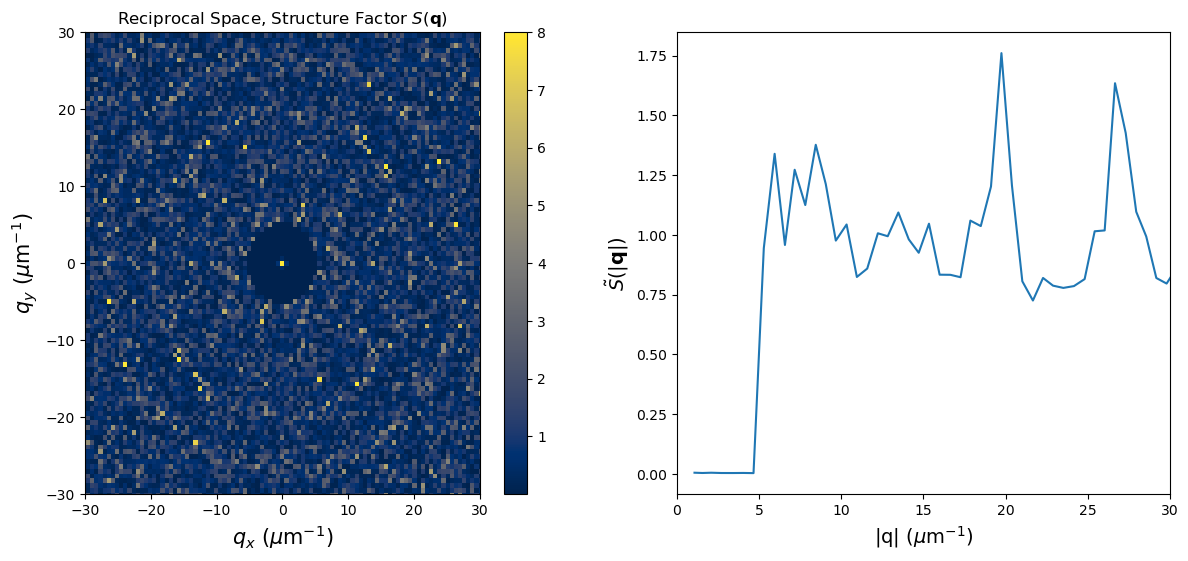

In [14]:
fig = tost.Visualize(opt_state1)
fig.plot_reciprocal_space(vmax=8,kmax=30)

From the structure factor plots, it can be seen that the first state is created successfully with the desired reciprocal-space features.

Now, we add the next species into the system. The newly added particles are now the degree of freedom while the first one remains masked. 

#### <span style="color:red">Note : While the previous state remains masked in this optimization, it must be emphasized that it still interacts with the overall system and the structure-factor and pair-correlation in the objective function still accounts for its presence. </span>

In [ ]:
input = points.positions[Species[1]][:,:-1]
masked_pos = opt_state1.positions[:,:-1]

opt_r = opt.optimize(q_f = q_f,
                     D0=points.diameter + 0.002, #slight increase just to ensure no overlaps until `points.diameter`
                     positions=input,
                     masked_pos=masked_pos,
                     tol=1e-9 
                     )

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          266     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.49055D-01    |proj g|=  4.38844D-02

At iterate    1    f=  1.05059D-01    |proj g|=  2.72219D-02

At iterate    2    f=  4.70964D-02    |proj g|=  9.73986D-03

At iterate    3    f=  2.50303D-02    |proj g|=  5.66245D-03

At iterate    4    f=  1.24795D-02    |proj g|=  4.14659D-03

At iterate    5    f=  6.16675D-03    |proj g|=  1.72761D-03

At iterate    6    f=  3.66736D-03    |proj g|=  8.48177D-04

At iterate    7    f=  2.50858D-03    |proj g|=  7.85251D-04

At iterate    8    f=  1.71503D-03    |proj g|=  5.46889D-04

At iterate    9    f=  1.11326D-03    |proj g|=  4.29976D-04

At iterate   10    f=  8.25575D-04    |proj g|=  2.92052D-04

At iterate   11    f=  6.49013D-04    |proj g|=  3.06901D-04

At iterate   12    f=  5.17607D-04    |proj g|=  2.61980D-04

At iterate   13    f=  3.6

Our second state is also tuned now. This can also be declared in a separate `PointDistribution` like before.

In [ ]:
opt_state2 = tost.PointDistribution(opt.opt_positions,diameter=points.diameter,BoxSize=points.BoxSize)
collection_1 = tost.PointDistribution(np.vstack([opt_state1.positions[:,:-1],opt_state2.positions[:,:-1]]),diameter=points.diameter,BoxSize=points.BoxSize)

The overlap condition can be checked again...

In [18]:
print ( opt_state2.overlap(points.diameter)[0], collection_1.overlap(points.diameter)[0])

0.0 0.0


### Clearly, the optimization successfully avoided overlaps of the new particles among themselves as well as with the masked particles.

[<Axes: title={'center': 'Reciprocal Space, Structure Factor $S(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{S}(|\\mathbf{q}|)$'>]

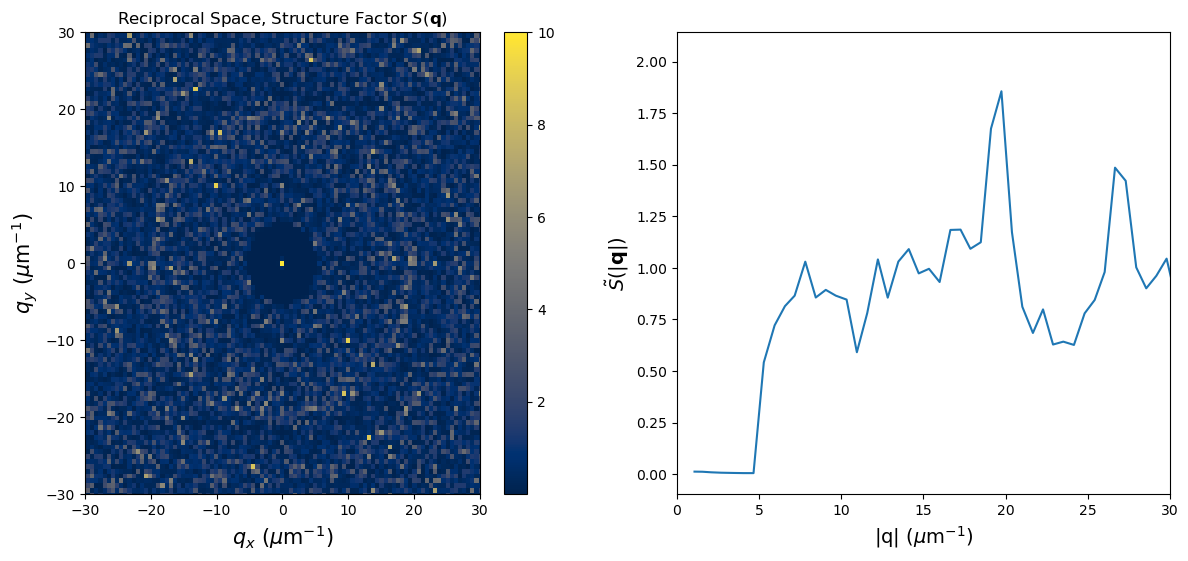

In [ ]:
fig = tost.Visualize(collection_1)
fig.plot_reciprocal_space(kmax=30,vmax=10)

Now, we add the final species into the system while keeping the first two species fixed during the optimization. Since the complexity of the problem is now much higher than before, we add minor random perturbations to each degree of freedom (only last species) to ensure the gradient descent (L-BFGS-B) does not get stuck in a local-minima every time.

In [ ]:
dr = np.random.uniform(-0.1,0.1,[particles_per_species,2]) #minor perturbations 
input = points.positions[Species[2]][:,:-1] + dr 
masked_pos = collection_1.positions[:,:-1] 

opt_r = opt.optimize(q_f = q_f,
                     D0=points.diameter+0.01, #slightly increase the diameter to ensure no overlaps until `points.diameter`
                     positions=input,
                     masked_pos=masked_pos,
                     tol=1e-9)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =          266     M =           10

At X0         2 variables are exactly at the bounds

At iterate    0    f=  8.82329D-02    |proj g|=  1.98314D-02

At iterate    1    f=  7.85003D-02    |proj g|=  1.57423D-02

At iterate    2    f=  3.57265D-02    |proj g|=  7.96580D-03

At iterate    3    f=  1.74661D-02    |proj g|=  3.43876D-03

At iterate    4    f=  7.78814D-03    |proj g|=  1.64904D-03

At iterate    5    f=  4.82910D-03    |proj g|=  1.20917D-03

At iterate    6    f=  3.31744D-03    |proj g|=  8.42193D-04

At iterate    7    f=  2.54398D-03    |proj g|=  5.13997D-04

At iterate    8    f=  1.76466D-03    |proj g|=  3.10464D-04

At iterate    9    f=  1.34705D-03    |proj g|=  3.22708D-04

At iterate   10    f=  1.04797D-03    |proj g|=  2.10510D-04

At iterate   11    f=  8.73788D-04    |proj g|=  1.84934D-04

At iterate   12    f=  7.33657D-04    |proj g|=  2.59012D-04

At iterate   13    f=  6.2

In [ ]:
opt_state3 = tost.PointDistribution(opt.opt_positions,diameter=points.diameter,BoxSize=points.BoxSize)
collection_2 = tost.PointDistribution(np.vstack([collection_1.positions[:,:-1],opt_state3.positions[:,:-1]]),diameter=points.diameter,BoxSize=points.BoxSize)

Check the overlap condition of the entire system now.

In [43]:
print (opt_state3.overlap(points.diameter)[0],collection_2.overlap(0.30)[0])

0.0 0.0


#### All the 3 states are now ready. Let's compile and visualize the results.

<Axes: title={'center': 'Point Distribution, mean interparticle distance = 0.8671099695241199'}, xlabel='X ($\\mu$m)', ylabel='Y ($\\mu$m)'>

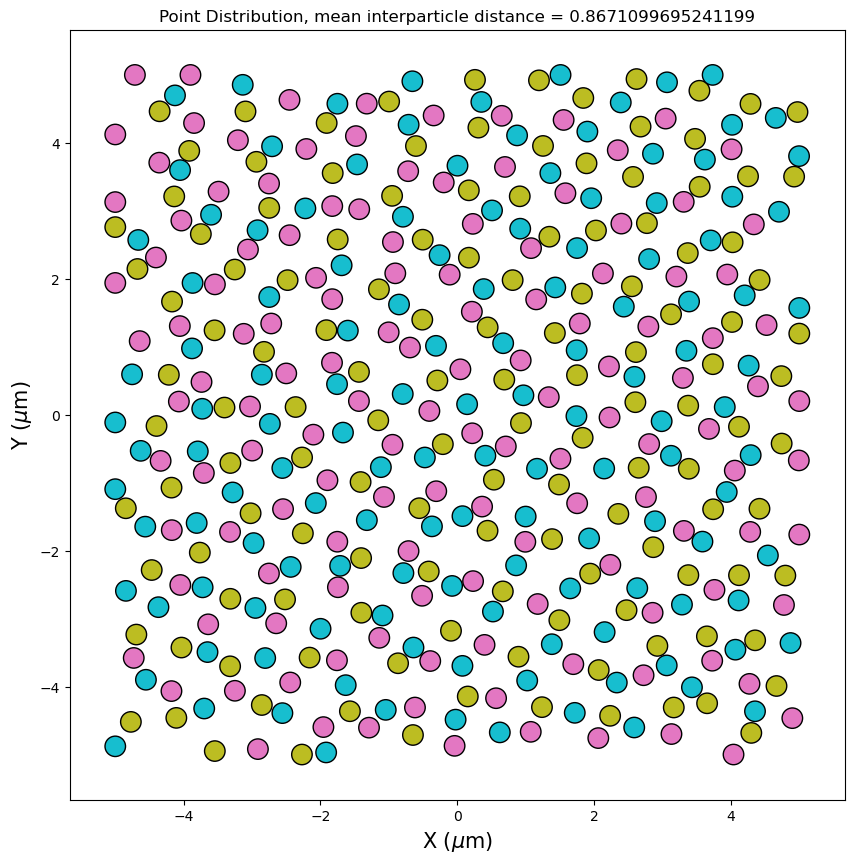

In [ ]:
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
fig = tost.Visualize(opt_state1) #first state
fig.plot_distribution(ax) 
fig = tost.Visualize(opt_state2)
fig.plot_distribution(ax,facecolor='tab:pink')
fig = tost.Visualize(opt_state3)
fig.plot_distribution(ax,facecolor='tab:cyan')

One can see that each species are not simply in a local cluster but rather spread out throughout the simulation domain all while avoiding any overlaps individually and among other species. Let's visualize the reciprocal space response of the overall system.

[<Axes: title={'center': 'Reciprocal Space, Structure Factor $S(\\mathbf{q})$'}, xlabel='$q_{x}$ ($\\mu$m$^{-1}$)', ylabel='$q_{y}$ ($\\mu$m$^{-1}$)'>,
 <Axes: xlabel='|q| ($\\mu$m$^{-1}$)', ylabel='$\\tilde{S}(|\\mathbf{q}|)$'>]

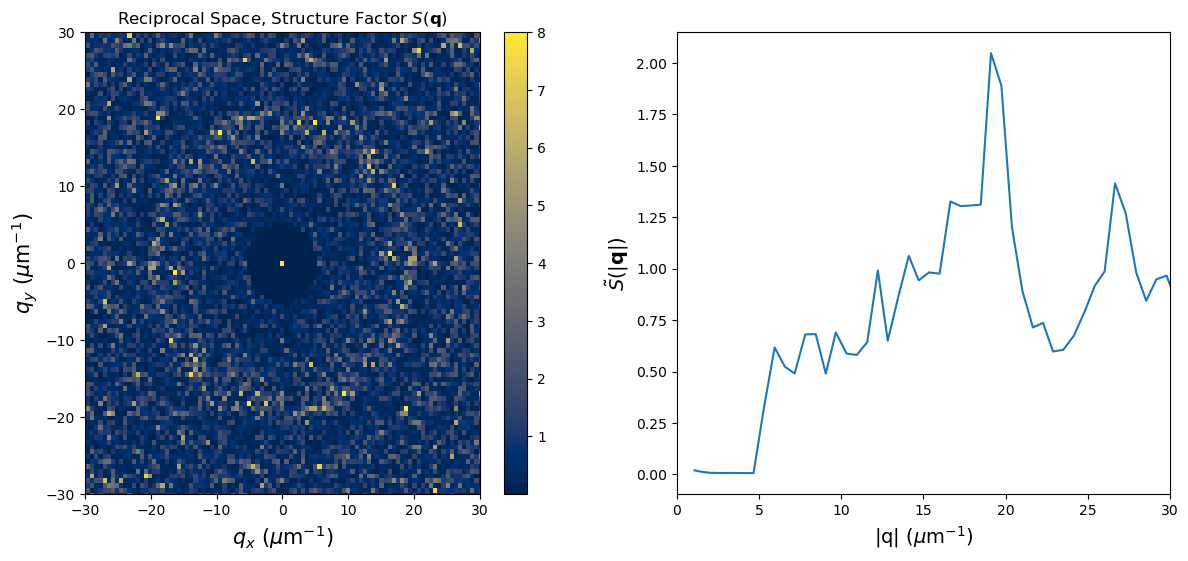

In [ ]:
fig = tost.Visualize(collection_2)
fig.plot_reciprocal_space(kmax=30,vmax=8)

The results confirm that the individual species as well as the overall system are hyperuniform.